In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB

In [4]:
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]

X_subset = X[:35000]
y_subset = y[:35000]

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, train_size=30000, test_size=5000, random_state=42
)
print("Finished fetching MNIST dataset!")

Fetching MNIST dataset...
Finished fetching MNIST dataset!


In [16]:
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape:  {X_test.shape}")
print(f"Training Labels:     {y_train.shape}")
print(f"Unique Classes:      {np.unique(y_train)}")

print(f"Min pixel value: {X_train.min()}")
print(f"Max pixel value: {X_train.max()}")

Training Data Shape: (30000, 784)
Testing Data Shape:  (5000, 784)
Training Labels:     (30000,)
Unique Classes:      ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Min pixel value: 0
Max pixel value: 255


In [17]:
def plot_digits(instances, labels, images_per_row=5):
    n_images = len(instances)
    n_rows = (n_images - 1) // images_per_row + 1
    
    plt.figure(figsize=(images_per_row * 2, n_rows * 2))
    
    for i in range(n_images):
        plt.subplot(n_rows, images_per_row, i + 1)
        # reshape the 784-pixel flat array back into a 28x28 image
        image = instances[i].reshape(28, 28)
        plt.imshow(image, cmap="binary")
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

Visualizing a sample of the MNIST training data:


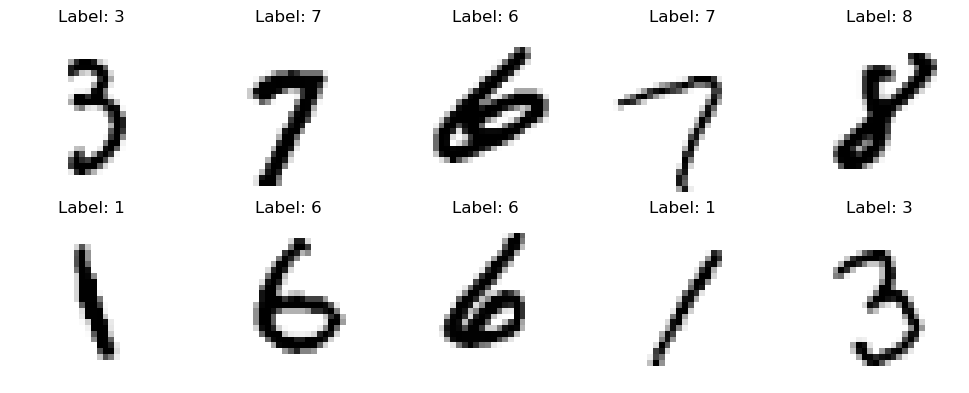

In [18]:
print("Visualizing a sample of the MNIST training data:")
plot_digits(X_train[:10], y_train[:10])

In [21]:
print("\n--- Class Distribution in Training Set ---")
print(pd.Series(y_train).value_counts().sort_index())


--- Class Distribution in Training Set ---
0    2927
1    3399
2    2946
3    3077
4    2930
5    2722
6    2973
7    3112
8    2887
9    3027
Name: count, dtype: int64


In [22]:
# scale the features (important for algorithms like KNN and SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
rf_clf = RandomForestClassifier(
    n_estimators=150, 
    max_depth=None, 
    n_jobs=-1, 
    random_state=42
)

In [24]:
knn_clf = KNeighborsClassifier(
    n_neighbors=5, 
    weights='distance', 
    n_jobs=-1
)

In [25]:
sgd_clf = SGDClassifier(
    max_iter=1000, 
    tol=1e-3, 
    loss='hinge',    # Standard SVM-like loss
    random_state=42
)

In [26]:
nb_clf = GaussianNB(
    var_smoothing=1e-9 # Default, but good to acknowledge for stability
)

In [27]:
# Ensemble Classifier using Hard Voting
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('knn', knn_clf),
        ('sgd', sgd_clf),
        ('nb', nb_clf)
    ],
    voting='hard' 
)

In [28]:
print("\n--- Model Evaluation Results ---")
for clf in (rf_clf, knn_clf, sgd_clf, nb_clf, voting_clf):
    clf.fit(X_train_scaled, y_train)
    
    y_pred = clf.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"{clf.__class__.__name__}: {accuracy:.4f} ({accuracy * 100:.2f}%)")


--- Model Evaluation Results ---
RandomForestClassifier: 0.9638 (96.38%)
KNeighborsClassifier: 0.9394 (93.94%)
SGDClassifier: 0.9054 (90.54%)
GaussianNB: 0.5394 (53.94%)
VotingClassifier: 0.9506 (95.06%)


In [29]:
from sklearn.metrics import classification_report

models = [rf_clf, knn_clf, sgd_clf, nb_clf, voting_clf]
model_names = ["Random Forest", "KNN", "SGD", "Naive Bayes", "Ensemble (Hard Voting)"]

for name, clf in zip(model_names, models):
    clf.fit(X_train_scaled, y_train)
    score = clf.score(X_test_scaled, y_test)
    print(f"{name:22} Accuracy: {score:.4f}")

y_pred = voting_clf.predict(X_test_scaled)
print("\nDetailed Ensemble Report:")
print(classification_report(y_test, y_pred))

Random Forest          Accuracy: 0.9638
KNN                    Accuracy: 0.9394
SGD                    Accuracy: 0.9054
Naive Bayes            Accuracy: 0.5394
Ensemble (Hard Voting) Accuracy: 0.9506

Detailed Ensemble Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       507
           1       0.95      0.98      0.97       603
           2       0.94      0.95      0.95       488
           3       0.94      0.94      0.94       499
           4       0.95      0.94      0.94       480
           5       0.97      0.93      0.95       428
           6       0.96      0.97      0.97       492
           7       0.97      0.94      0.96       520
           8       0.93      0.92      0.93       486
           9       0.92      0.94      0.93       497

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



In [30]:
sgd_soft = SGDClassifier(
    loss='log_loss', 
    max_iter=1000, 
    tol=1e-3, 
    random_state=42
)

In [31]:
rf_soft = RandomForestClassifier(
    n_estimators=150, 
    n_jobs=-1, 
    random_state=42
)

In [32]:
knn_soft = KNeighborsClassifier(
    n_neighbors=5, 
    weights='distance', 
    n_jobs=-1
)

In [33]:
nb_soft = GaussianNB()

In [34]:
soft_voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_soft),
        ('knn', knn_soft),
        ('sgd', sgd_soft),
        ('nb', nb_soft)
    ],
    voting='soft'
)

In [35]:
print("--- Soft Voting vs Individual Models ---")
for name, clf in [
    ("Random Forest", rf_soft),
    ("KNN", knn_soft),
    ("SGD (Log)", sgd_soft),
    ("Naive Bayes", nb_soft),
    ("Ensemble (Soft)", soft_voting_clf)
]:
    clf.fit(X_train_scaled, y_train)
    score = clf.score(X_test_scaled, y_test)
    print(f"{name:18} Accuracy: {score:.4f}")

--- Soft Voting vs Individual Models ---
Random Forest      Accuracy: 0.9638
KNN                Accuracy: 0.9394
SGD (Log)          Accuracy: 0.9038
Naive Bayes        Accuracy: 0.5394
Ensemble (Soft)    Accuracy: 0.9232


In [37]:
soft_models = [rf_soft, knn_soft, sgd_soft, nb_soft, soft_voting_clf]
soft_model_names = ["Random Forest", "KNN", "SGD (Log)", "Naive Bayes", "Ensemble (Soft Voting)"]

print("--- Soft Voting Performance Comparison ---")
for name, clf in zip(soft_model_names, soft_models):
    clf.fit(X_train_scaled, y_train)
    score = clf.score(X_test_scaled, y_test)
    print(f"{name:25} Accuracy: {score:.4f}")

y_pred_soft = soft_voting_clf.predict(X_test_scaled)
print("\nDetailed Soft Ensemble Report:")
print(classification_report(y_test, y_pred_soft))

--- Soft Voting Performance Comparison ---
Random Forest             Accuracy: 0.9638
KNN                       Accuracy: 0.9394
SGD (Log)                 Accuracy: 0.9038
Naive Bayes               Accuracy: 0.5394
Ensemble (Soft Voting)    Accuracy: 0.9232

Detailed Soft Ensemble Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       507
           1       0.96      0.97      0.97       603
           2       0.96      0.90      0.93       488
           3       0.93      0.90      0.91       499
           4       0.96      0.90      0.93       480
           5       0.97      0.84      0.90       428
           6       0.95      0.95      0.95       492
           7       0.96      0.90      0.93       520
           8       0.79      0.91      0.85       486
           9       0.82      0.96      0.89       497

    accuracy                           0.92      5000
   macro avg       0.93      0.92      0.92      5000
weight

## Part 2 — Reflection & Summary
### What I Learned About Ensemble Learning

- Ensemble learning is the process of combining multiple diverse machine learning models to create a single "meta-model" that is generally more robust than its individual components. I learned that there are two primary ways to aggregate these predictions:

- Hard Voting: The ensemble acts like a democracy, where each model casts one "vote" for a class, and the class with the majority wins.

- Soft Voting: The ensemble calculates the average of the predicted probabilities across all models. This allows models that are highly confident in their prediction to have a greater influence on the final result.

### When Ensembles Seem Beneficial

- Ensembles are most beneficial when the individual models are diverse-meaning they make different types of errors. In this activity, combining a tree-based model (Random Forest), a distance-based model (KNN), and a linear model (SGD) allowed the ensemble to "cancel out" the specific weaknesses of a single algorithm. Ensembles are particularly useful when:

  - You want to reduce the variance or bias of a single model.

  - The dataset is complex (like handwritten digits), where different features might be captured better by different algorithms.

  - The individual models have relatively high accuracy but differ in which specific instances they misclassify.

### Observations and Surprises
- The Power of Random Forest: In both tests, the Random Forest was the strongest individual performer (96.38%).

- The Naive Bayes Weakness: Gaussian Naive Bayes struggled significantly with the MNIST dataset (~53.94% accuracy). This is likely because Naive Bayes assumes features are independent, which isn't true for images where neighboring pixels are highly correlated.

- The Surprise (Hard vs Soft): Surprisingly, the Hard Voting ensemble (95.06%) performed significantly better than the Soft Voting ensemble (92.32%). Typically, Soft Voting is expected to be more accurate because it uses more information (probabilities).

- The "Anchor" Effect: I observed that the inclusion of the weak Naive Bayes model likely "dragged down" the Soft Voting ensemble more than the Hard Voting one. In Soft Voting, if a weak model is very confident about a wrong answer, it can skew the average probability and lead the ensemble astray.